# Futures Positioning: CFTC Commitment of Traders Analysis

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.3 (Fundamentals Across the Asset-Class Spectrum)

## Purpose

In a futures market every long position is somebody's short, so the aggregate is always zero
and tells you nothing. What is informative is *who* is on each side. The Commodity Futures
Trading Commission requires any trader holding more than a reporting threshold to disclose
their positions weekly, sorts them into categories by what kind of firm they are, and publishes
the totals for free in the Commitment of Traders report.

That gives a weekly picture of how each kind of participant is positioned: which way the hedge
funds lean, whether the physical producers are hedged more than usual, and where the dealers
are absorbing the other side. This notebook loads those reports, turns raw contract counts into
a comparable measure of how unusual the current positioning is, attaches the date the report
became public, and joins it onto futures prices at that date rather than at the date it
describes.

## Learning Objectives

After completing this notebook, you will be able to:

- Name the trader categories in each of the two report formats and say which kind of firm
  each one holds.
- Load a product's report history and resolve the several CFTC contract markets that share one
  product code down to the one that carries the position.
- Turn a net contract count into a rolling z-score, and say what window it is measured against.
- Compute the date a report became public and join it onto a daily price series at that date,
  so that every session reads only reports already published.
- Build a contrarian signal from extreme positioning and a change signal from a weekly move,
  with the threshold for the change measured on prior weeks only.
- Compare positioning extremes across asset classes and say whether they arrive together.

## Prerequisites

Two free downloads, neither of which needs a key or a subscription. The first is the COT
archive; the second is the S&P 500 ETF, whose sessions Part 4 joins the reports onto.

```bash
python data/futures/positioning/cot_download.py --products ES,CL,GC   # this notebook's subset
python data/etfs/market/download.py --symbol SPY                      # the price series
```

## Cross-References

- **Upstream**: `data/futures/positioning/cot_download.py` (CFTC COT reports, weekly, free)
- **Downstream**: `08_financial_features/03_structural_cross_instrument_features.py` (sentiment features)
- **Related**: [`07_macro_data_alignment`](07_macro_data_alignment.ipynb) (the same publication-date correction on macro series)

In [1]:
"""Futures Positioning: CFTC Commitment of Traders Analysis - track institutional positioning for contrarian signals."""

import plotly.graph_objects as go
import polars as pl
from ml4t.data.cot import PRODUCT_MAPPINGS
from plotly.subplots import make_subplots

from data import load_etfs
from data.futures.loader import load_cot
from utils.style import COLORS, show_plotly_with_alt

Four settings decide what the notebook measures. The z-score window is the one that changes an
answer: at fifty-two weekly reports it asks how unusual today's positioning is against the
past year, which is short enough to adapt to a changed regime and long enough that a single
quarter cannot move the mean far.

In [2]:
EQUITY_PRODUCT = "ES"  # E-mini S&P 500; the worked example throughout
COMPARISON_PRODUCTS = ["ES", "CL", "GC"]  # equity index, energy, precious metal
PRICE_PROXY = "SPY"  # ships with the book and trades the US equity calendar the E-mini does
START_DATE = "2020-01-01"
ZSCORE_WEEKS = 52  # one year of weekly reports
EXTREME_Z = 2.0  # how many standard deviations counts as extreme positioning
CHANGE_WINDOW_WEEKS = 26  # window the weekly-change threshold is measured over
RELEASE_LAG_DAYS = 7  # Tuesday positions, published Friday; usable from the next Tuesday

## 1. What is in a COT report

Positions are recorded as of the close on **Tuesday** and published on **Friday afternoon**.
The report gives, for each trader category, the number of contracts held long and the number
held short. The difference is the category's **net position**: positive means the category is
collectively long.

The CFTC publishes two formats, and which one a product gets depends on what it is.

| Format | Products | Categories |
|--------|----------|------------|
| Traders in Financial Futures | Equity index, rates, currencies | Dealers, asset managers, leveraged money, other reportables, non-reportables |
| Disaggregated | Physical commodities | Producers and merchants, swap dealers, managed money, other reportables |

The category names differ but the roles line up. **Dealers** and **swap dealers** are
intermediaries: they take the other side of what their clients want and hedge the residue.
**Asset managers** are long-only institutions whose positions move with allocation decisions
rather than with views on the next few weeks. **Leveraged money** and **managed money** are
hedge funds and commodity trading advisors, the participants who take directional risk
deliberately and who unwind it quickly. **Producers and merchants** hedge physical inventory,
which is why a commodity's commercial category is read as informed about that commodity.

The reading that follows from this is that an extreme in the speculative category is worth
attention: hedge funds crowded on one side have no one left to buy from, and the position has
to be unwound eventually.

In [3]:
covered = {
    "Equity index": ["ES", "NQ", "RTY", "YM"],
    "Currency": ["6E", "6J", "6B", "6C", "6A"],
    "Interest rate": ["ZN", "ZB", "ZF", "ZT"],
    "Energy": ["CL", "NG", "RB", "HO"],
    "Metals": ["GC", "SI", "HG", "PL"],
    "Agricultural": ["ZC", "ZW", "ZS", "ZM", "ZL"],
    "Crypto": ["BTC", "ETH"],
    "Volatility": ["VX"],
}
catalogue = pl.DataFrame(
    [
        {
            "asset_class": asset_class,
            "product": product,
            "description": PRODUCT_MAPPINGS[product].description
            if product in PRODUCT_MAPPINGS
            else None,
            "report_format": PRODUCT_MAPPINGS[product].report_type
            if product in PRODUCT_MAPPINGS
            else None,
        }
        for asset_class, products in covered.items()
        for product in products
    ]
)
print(f"Products the downloader maps: {len(PRODUCT_MAPPINGS)}")
print(f"Of the ones listed here, unmapped: {catalogue['description'].is_null().sum()}")
catalogue

Products the downloader maps: 36
Of the ones listed here, unmapped: 0


asset_class,product,description,report_format
str,str,str,str
"""Equity index""","""ES""","""E-mini S&P 500""","""traders_in_financial_futures_f…"
"""Equity index""","""NQ""","""E-mini NASDAQ-100""","""traders_in_financial_futures_f…"
"""Equity index""","""RTY""","""E-mini Russell 2000""","""traders_in_financial_futures_f…"
"""Equity index""","""YM""","""E-mini Dow Jones""","""traders_in_financial_futures_f…"
"""Currency""","""6E""","""Euro FX""","""traders_in_financial_futures_f…"
…,…,…,…
"""Agricultural""","""ZM""","""Soybean Meal""","""disaggregated_fut"""
"""Agricultural""","""ZL""","""Soybean Oil""","""disaggregated_fut"""
"""Crypto""","""BTC""","""Bitcoin""","""traders_in_financial_futures_f…"


## 2. Loading a product, and the duplicate rows

The CFTC reports on **contract markets**, not on the ticker a trader thinks in. Several
distinct contract markets map to one product code: the E-mini S&P 500 shares its code with a
smaller related contract, and crude oil with more than one delivery specification. The
downloader writes them all, so a product's history has more than one row on many report dates.

Leaving them in would double-count the position and make any statistic over the series
meaningless. The rule used here is to keep, on each date, the row with the largest open
interest, which is the market that actually carries the position. What makes that safe rather
than convenient is that the choice has to be *stable*: if the largest market changed from week
to week, the resulting series would be jumping between contracts and its week-over-week changes
would be fiction.

The loader carries no contract-market identifier, so stability cannot be read off directly.
What can be measured is the margin: how many times larger the kept market is than the one
dropped beside it. A margin that never narrows toward one makes a change of rank implausible,
which is evidence and not proof.

In [4]:
def keep_deepest_market(reports: pl.DataFrame) -> pl.DataFrame:
    """One row per report date: the contract market carrying the most open interest."""
    return (
        reports.sort(["product", "report_date", "open_interest"], descending=[False, False, True])
        .unique(subset=["product", "report_date"], keep="first")
        .sort("report_date")
    )

In [5]:
raw_equity = load_cot(products=[EQUITY_PRODUCT], start_date=START_DATE)
equity = keep_deepest_market(raw_equity)

print(f"Rows as downloaded: {len(raw_equity):,}")
print(f"Report dates: {raw_equity['report_date'].n_unique():,}")
print(f"Rows after keeping the deepest market: {len(equity):,}")
print(f"Reports covering: {equity['report_date'].min()} to {equity['report_date'].max()}")

Rows as downloaded: 585
Report dates: 330
Rows after keeping the deepest market: 330
Reports covering: 2020-01-07 to 2026-04-28


In [6]:
margins = (
    raw_equity.group_by("report_date")
    .agg(
        pl.len().alias("markets"),
        pl.col("open_interest").max().alias("deepest"),
        pl.col("open_interest").min().alias("shallowest"),
    )
    .filter(pl.col("markets") > 1)
    .with_columns(margin=pl.col("deepest") / pl.col("shallowest"))
)
print(f"Report dates carrying more than one market: {len(margins):,}")
print(f"Narrowest margin between the kept market and the next: {margins['margin'].min():.1f}x")
print(f"Median margin: {margins['margin'].median():.1f}x")
margins.sort("margin").head(3)

Report dates carrying more than one market: 255
Narrowest margin between the kept market and the next: 5.7x
Median margin: 13.1x


report_date,markets,deepest,shallowest,margin
date,u32,i64,i64,f64
2023-06-06,2,2500232,439321,5.691128
2023-06-13,2,2907468,490045,5.933063
2023-05-30,2,2494943,389284,6.409056


### The columns

The loader derives a net column for each category, which is the only column most analysis uses.

| Column | What it holds |
|--------|---------------|
| `open_interest` | Contracts outstanding across all traders |
| `lev_money_long`, `lev_money_short` | Hedge fund positions, gross |
| `lev_money_net` | Hedge funds long minus short |
| `asset_mgr_net` | Asset managers long minus short |
| `dealer_net` | Dealers long minus short |

A commodity's report uses `managed_money_net` for the speculative category rather than
`lev_money_net`, which is a naming difference and not a difference in what is measured, so the
comparison in Part 6 renames it.

In [7]:
equity.select("report_date", "open_interest", "dealer_net", "asset_mgr_net", "lev_money_net").tail(
    5
)

report_date,open_interest,dealer_net,asset_mgr_net,lev_money_net
date,i64,i64,i64,i64
2026-03-31,1947769,-819324,915718,-233412
2026-04-07,1929090,-808612,940435,-244483
2026-04-14,1959076,-693590,1003143,-420356
2026-04-21,1963317,-718629,1014927,-412321
2026-04-28,1959933,-705540,994815,-407490


## 3. From contracts to something comparable

A net position of two hundred thousand contracts means nothing on its own. It is large or
small only against how large that category's position usually is, and open interest grows over
the years, so even the same number means something different a decade apart. The standard
correction is a rolling z-score: how many standard deviations today's net position sits from
its own average over the last year.

Two details decide what the number means. The window is counted in **reports**, and reports are
weekly, so fifty-two of them is a year. And the window ends on the current report, which is
available at the moment the score is computed, so including it introduces no look-ahead; it
only means a single extreme reading pulls its own mean slightly toward itself.

In [8]:
def add_positioning_zscore(reports: pl.DataFrame, net_column: str, window: int) -> pl.DataFrame:
    """Add the rolling z-score of `net_column` over the trailing `window` reports."""
    mean = pl.col(net_column).rolling_mean(window)
    std = pl.col(net_column).rolling_std(window)
    return reports.with_columns(
        # A window in which the position never moved has no scale to measure against, so the
        # score is undefined rather than zero: zero would read as "exactly average".
        pl.when(std > 0)
        .then((pl.col(net_column) - mean) / std)
        .otherwise(None)
        .alias(f"{net_column}_zscore")
    )

In [9]:
equity = add_positioning_zscore(equity, "lev_money_net", ZSCORE_WEEKS)
scored = equity.drop_nulls("lev_money_net_zscore")

print(f"Reports with a z-score, once the window has filled: {len(scored):,} of {len(equity):,}")
print(f"Reports above +{EXTREME_Z}: {(scored['lev_money_net_zscore'] > EXTREME_Z).sum()}")
print(f"Reports below -{EXTREME_Z}: {(scored['lev_money_net_zscore'] < -EXTREME_Z).sum()}")
equity.select("report_date", "lev_money_net", "lev_money_net_zscore").tail(5)

Reports with a z-score, once the window has filled: 279 of 330
Reports above +2.0: 11
Reports below -2.0: 12


report_date,lev_money_net,lev_money_net_zscore
date,i64,f64
2026-03-31,-233412,1.929924
2026-04-07,-244483,1.749096
2026-04-14,-420356,-0.692207
2026-04-21,-412321,-0.546183
2026-04-28,-407490,-0.443814


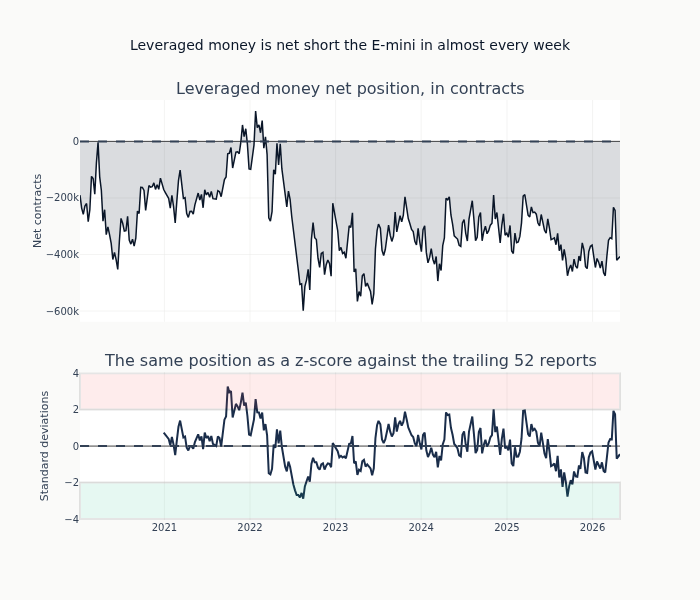

In [10]:
equity_pd = equity.to_pandas()

fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        "Leveraged money net position, in contracts",
        f"The same position as a z-score against the trailing {ZSCORE_WEEKS} reports",
    ),
    row_heights=[0.6, 0.4],
    vertical_spacing=0.12,
    shared_xaxes=True,
)
fig.add_trace(
    go.Scatter(
        x=equity_pd["report_date"],
        y=equity_pd["lev_money_net"],
        mode="lines",
        line=dict(color=COLORS["blue"], width=1.5),
        fill="tozeroy",
        fillcolor="rgba(10, 22, 40, 0.15)",  # translucent COLORS["blue"]
    ),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)
fig.add_trace(
    go.Scatter(
        x=equity_pd["report_date"],
        y=equity_pd["lev_money_net_zscore"],
        mode="lines",
        line=dict(color=COLORS["slate"], width=2),
    ),
    row=2,
    col=1,
)
fig.add_hrect(y0=EXTREME_Z, y1=4, fillcolor=COLORS["negative"], opacity=0.1, row=2, col=1)
fig.add_hrect(y0=-4, y1=-EXTREME_Z, fillcolor=COLORS["positive"], opacity=0.1, row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)
fig.update_yaxes(title_text="Net contracts", row=1, col=1)
fig.update_yaxes(title_text="Standard deviations", row=2, col=1)
fig.update_layout(
    height=600,
    title="Leveraged money is net short the E-mini in almost every week",
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "Two stacked panels sharing a time axis: leveraged money's net position in contracts, filled to a zero line and below it throughout, and the same position as a z-score against the trailing year with shaded bands beyond plus and minus two.",
)

The two panels are the same data and answer different questions. The upper one says the
position is short and roughly how short; the lower one says whether it is unusually so. A
position that is short every week is not a signal, and the z-score is what turns a level into
one.

## 4. When the report becomes usable

The report describes Tuesday and is published on Friday afternoon, after the close in most
markets a US-hours strategy trades. Anything that reads it on its Tuesday date is reading a
number three days before it existed, and a strategy backtested that way trades on positions
that had not been disclosed.

The correction is the same as the macro one in the previous notebook: give every report the
date it became usable, and join on that. The lag used here is seven days, taking Tuesday to
the following Tuesday. Two days of that are slack rather than schedule. One covers the Friday
release landing after the close, so a same-day rule would have the strategy trading on a
report it could not have read. The other covers the CFTC's own holiday policy, which pushes a
release to the next business day whenever a federal holiday falls inside the report week, so
some Friday releases arrive on the Monday.

**This is a schedule bound rather than a recorded release date.** The downloaded reports carry
no publication timestamp, so the correction is an assumption about when each one appeared, made
deliberately late. Where a feed does carry release timestamps, join on those instead; where it
does not, a bound that is a day or two conservative costs a little signal and an aggressive one
costs the validity of the whole backtest.

In [11]:
equity = equity.with_columns(
    available_from=pl.col("report_date").dt.offset_by(f"{RELEASE_LAG_DAYS}d")
)
equity.select("report_date", "available_from", "lev_money_net", "lev_money_net_zscore").tail(5)

report_date,available_from,lev_money_net,lev_money_net_zscore
date,date,i64,f64
2026-03-31,2026-04-07,-233412,1.929924
2026-04-07,2026-04-14,-244483,1.749096
2026-04-14,2026-04-21,-420356,-0.692207
2026-04-21,2026-04-28,-412321,-0.546183
2026-04-28,2026-05-05,-407490,-0.443814


Joining onto prices is where the date does its work. The price series used here is the S&P 500
ETF rather than the E-mini itself: the two track the same index, the ETF's sessions are the US
equity trading calendar an E-mini strategy trades on, and its download is free, whereas the
CME futures panel needs a paid market-data subscription. A backward as-of join on
`available_from` gives each session the most recent report that had been published by then, so
a session late in the week still carries the previous week's report until the new one clears
its lag.

In [12]:
prices = (
    load_etfs(symbols=[PRICE_PROXY], start_date=START_DATE)
    .select(session_date="timestamp", close="close")
    .sort("session_date")
)
sessions = prices.join_asof(
    equity.select("available_from", "report_date", "lev_money_net", "lev_money_net_zscore").sort(
        "available_from"
    ),
    left_on="session_date",
    right_on="available_from",
    strategy="backward",
)

print(f"Trading sessions: {len(sessions):,}")
print(f"Sessions with no report yet published: {sessions['report_date'].is_null().sum()}")
print(
    "Median age of the attached report, in days: "
    f"{int((sessions['session_date'] - sessions['report_date']).dt.total_days().median())}"
)
sessions.tail(8)

Trading sessions: 1,508
Sessions with no report yet published: 8
Median age of the attached report, in days: 9


session_date,close,available_from,report_date,lev_money_net,lev_money_net_zscore
date,f64,date,date,i64,f64
2025-12-19,678.736389,2025-12-16,2025-12-09,-450002,-1.471427
2025-12-22,682.964844,2025-12-16,2025-12-09,-450002,-1.471427
2025-12-23,686.086304,2025-12-23,2025-12-16,-389167,-0.615893
2025-12-24,688.499695,2025-12-23,2025-12-16,-389167,-0.615893
2025-12-26,688.429871,2025-12-23,2025-12-16,-389167,-0.615893
2025-12-29,685.976562,2025-12-23,2025-12-16,-389167,-0.615893
2025-12-30,685.138916,2025-12-30,2025-12-23,-371060,-0.356605
2025-12-31,680.062744,2025-12-30,2025-12-23,-371060,-0.356605


The median age of the attached report is what the join costs: on any given session the newest
available positioning is about a week old, and that is a property of the data rather than
something the pipeline can improve.

## 5. Two signals, and one threshold that has to be measured carefully

A **contrarian** signal fades an extreme: the signal is short when the speculative category is
crowded long, and long when it is crowded short. A **change** signal reacts to the size of a weekly
move rather than the level, on the reading that a large repositioning matters whatever the
starting point.

The change signal needs a threshold for what counts as large, and the natural one is the
standard deviation of recent weekly changes. That standard deviation has to be measured on
weeks *before* the one being tested. A rolling window ending on the current week includes the
very change it is judging, which drags the threshold toward whatever value it is being compared
with and makes a genuinely large move harder to flag the larger it is.

In [13]:
def add_signals(reports: pl.DataFrame, net_column: str) -> pl.DataFrame:
    """Add a contrarian signal from the z-score and a change signal from the weekly move."""
    weekly_change = pl.col(net_column).diff()
    # Shifted by one report, so the threshold is built from weeks strictly before this one.
    prior_change_std = weekly_change.rolling_std(CHANGE_WINDOW_WEEKS).shift(1)
    return reports.with_columns(
        weekly_change=weekly_change,
        change_threshold=prior_change_std,
        contrarian_signal=pl.when(pl.col(f"{net_column}_zscore") > EXTREME_Z)
        .then(pl.lit(-1))
        .when(pl.col(f"{net_column}_zscore") < -EXTREME_Z)
        .then(pl.lit(1))
        .otherwise(pl.lit(0)),
    ).with_columns(
        change_signal=pl.when(pl.col("weekly_change") > pl.col("change_threshold"))
        .then(pl.lit(1))
        .when(pl.col("weekly_change") < -pl.col("change_threshold"))
        .then(pl.lit(-1))
        .otherwise(pl.lit(0))
    )

In [14]:
signalled = add_signals(equity, "lev_money_net")
signalled.group_by("contrarian_signal").len().sort("contrarian_signal")

contrarian_signal,len
i32,u32
-1,11
0,307
1,12


In [15]:
signalled.select(
    "report_date",
    "available_from",
    "lev_money_net",
    "lev_money_net_zscore",
    "weekly_change",
    "change_threshold",
    "contrarian_signal",
    "change_signal",
).tail(8)

report_date,available_from,lev_money_net,lev_money_net_zscore,weekly_change,change_threshold,contrarian_signal,change_signal
date,date,i64,f64,i64,f64,i32,i32
2026-03-10,2026-03-17,-349989,0.197371,56351,37476.368822,0,1
2026-03-17,2026-03-24,-340507,0.38097,9482,38449.652321,0,0
2026-03-24,2026-03-31,-344127,0.372438,-3620,36395.380223,0,0
2026-03-31,2026-04-07,-233412,1.929924,110715,36226.96653,0,1
2026-04-07,2026-04-14,-244483,1.749096,-11071,41816.90476,0,0
2026-04-14,2026-04-21,-420356,-0.692207,-175873,41523.498158,0,-1
2026-04-21,2026-04-28,-412321,-0.546183,8035,54377.182982,0,0
2026-04-28,2026-05-05,-407490,-0.443814,4831,54169.173603,0,0


## 6. Do positioning extremes arrive together?

A contrarian rule applied across several products is only diversifying if the products reach
their extremes at different times. If speculative positioning were crowded in equities, energy
and metals in the same weeks, the rule would be one bet in three places.

In [16]:
SPECULATIVE_COLUMN = {"ES": "lev_money_net", "CL": "managed_money_net", "GC": "managed_money_net"}

scored_products = {}
for product in COMPARISON_PRODUCTS:
    reports = keep_deepest_market(load_cot(products=[product], start_date=START_DATE))
    column = SPECULATIVE_COLUMN[product]
    scored_products[product] = add_positioning_zscore(
        reports.with_columns(speculative_net=pl.col(column)), "speculative_net", ZSCORE_WEEKS
    )
    print(f"{product}: {len(reports):,} reports, speculative category read from {column!r}")

ES: 330 reports, speculative category read from 'lev_money_net'
CL: 330 reports, speculative category read from 'managed_money_net'
GC: 330 reports, speculative category read from 'managed_money_net'


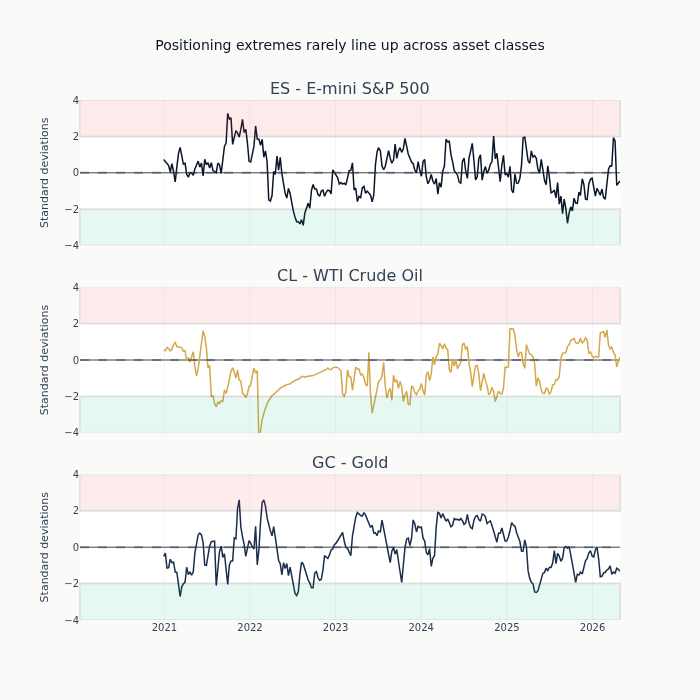

In [17]:
fig = make_subplots(
    rows=len(COMPARISON_PRODUCTS),
    cols=1,
    subplot_titles=[
        f"{p} - {PRODUCT_MAPPINGS[p].description}" if p in PRODUCT_MAPPINGS else p
        for p in COMPARISON_PRODUCTS
    ],
    vertical_spacing=0.08,
    shared_xaxes=True,
)
for row, (product, color) in enumerate(
    zip(COMPARISON_PRODUCTS, [COLORS["blue"], COLORS["amber"], COLORS["slate"]], strict=True), 1
):
    frame = scored_products[product].to_pandas()
    fig.add_trace(
        go.Scatter(
            x=frame["report_date"],
            y=frame["speculative_net_zscore"],
            mode="lines",
            line=dict(color=color, width=1.5),
        ),
        row=row,
        col=1,
    )
    fig.add_hrect(y0=EXTREME_Z, y1=4, fillcolor=COLORS["negative"], opacity=0.1, row=row, col=1)
    fig.add_hrect(y0=-4, y1=-EXTREME_Z, fillcolor=COLORS["positive"], opacity=0.1, row=row, col=1)
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], opacity=0.5, row=row, col=1)
fig.update_yaxes(title_text="Standard deviations", range=[-4, 4])
fig.update_layout(
    height=700,
    title="Positioning extremes rarely line up across asset classes",
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "Three stacked panels sharing a time axis, one per product, each showing the speculative category's positioning z-score with shaded bands beyond plus and minus two. The shaded excursions in the three panels fall in different weeks.",
)

Reading three panels for coincidence is a job for a number rather than an eye. Correlating the
three z-score series on the report dates they share says how much a rule applied to all three
is really one bet.

In [18]:
aligned = None
for product in COMPARISON_PRODUCTS:
    column = scored_products[product].select(
        "report_date", pl.col("speculative_net_zscore").alias(product)
    )
    aligned = column if aligned is None else aligned.join(column, on="report_date", how="inner")
aligned = aligned.drop_nulls()

print(f"Report dates all three products share: {len(aligned):,}")
# `corr` returns a square frame with no row labels, so the product names are put back on.
aligned.select(COMPARISON_PRODUCTS).corr().insert_column(
    0, pl.Series("product", COMPARISON_PRODUCTS)
)

Report dates all three products share: 279


product,ES,CL,GC
str,f64,f64,f64
"""ES""",1.0,-0.234704,0.184669
"""CL""",-0.234704,1.0,-0.180885
"""GC""",0.184669,-0.180885,1.0


## 7. Who takes the other side

Every contract one trader is long, another is short, so the net positions of all the report's
categories sum to zero. A financial futures report has five of them: the three plotted below
plus other reportables and non-reportables, and those two are large enough that the three alone
do not balance. The identity is worth measuring rather than asserting.

In [19]:
five_category_imbalance = equity.select(
    (
        pl.col("dealer_net")
        + pl.col("asset_mgr_net")
        + pl.col("lev_money_net")
        + (pl.col("other_rept_long") - pl.col("other_rept_short"))
        + pl.col("nonrept_net")
    )
    .abs()
    .alias("imbalance")
)
three_category_residual = equity.select(
    (pl.col("dealer_net") + pl.col("asset_mgr_net") + pl.col("lev_money_net"))
    .abs()
    .alias("residual")
)
print(
    f"Largest imbalance across all five categories: {five_category_imbalance['imbalance'].max():,}"
)
print(
    "Median size of what the three plotted categories leave over: "
    f"{three_category_residual['residual'].median():,.0f}"
)

Largest imbalance across all five categories: 0
Median size of what the three plotted categories leave over: 126,078


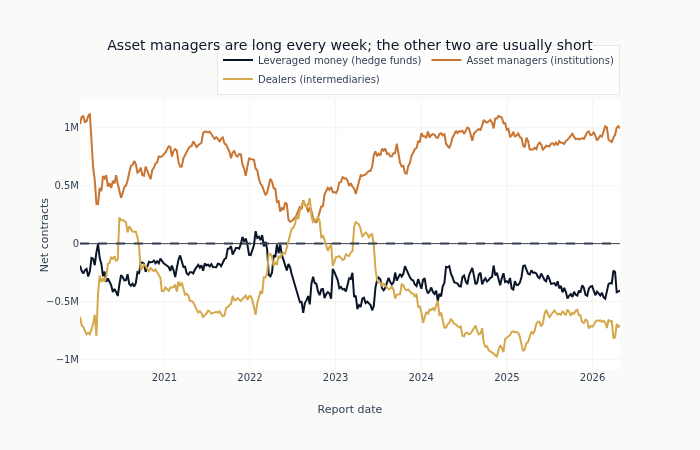

In [20]:
categories_pd = equity.to_pandas()

fig = go.Figure()
for column, label, color in [
    ("lev_money_net", "Leveraged money (hedge funds)", COLORS["blue"]),
    ("asset_mgr_net", "Asset managers (institutions)", COLORS["copper"]),
    ("dealer_net", "Dealers (intermediaries)", COLORS["amber"]),
]:
    fig.add_trace(
        go.Scatter(
            x=categories_pd["report_date"],
            y=categories_pd[column],
            mode="lines",
            name=label,
            line=dict(color=color, width=2),
        )
    )
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.update_layout(
    height=450,
    title="Asset managers are long every week; the other two are usually short",
    xaxis_title="Report date",
    yaxis_title="Net contracts",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
show_plotly_with_alt(
    fig,
    "Line chart of the net position of three trader categories over time. The asset manager line stays above zero throughout, while the leveraged money and dealer lines spend nearly all of it below zero.",
)

In [21]:
category_profile = pl.DataFrame(
    [
        {
            "category": label,
            "share_of_weeks_net_long": (equity[column] > 0).mean(),
            "median_net_position": int(equity[column].median()),
            "weekly_change_std": int(equity[column].diff().std()),
        }
        for column, label in [
            ("lev_money_net", "Leveraged money"),
            ("asset_mgr_net", "Asset managers"),
            ("dealer_net", "Dealers"),
        ]
    ]
).sort("weekly_change_std", descending=True)
category_profile

category,share_of_weeks_net_long,median_net_position,weekly_change_std
str,f64,i64,i64
"""Dealers""",0.142424,-491328,57056
"""Leveraged money""",0.027273,-296446,54956
"""Asset managers""",1.0,811862,46511


The table settles two things the chart leaves ambiguous. Asset managers hold a long position in
every week of the sample, so their sign carries no information and only their size does. And
the category that moves most from week to week is not the speculative one but the dealers, who
stand between the others and absorb what they do. A feature built on "how much did the
speculators move" is therefore measuring a smaller part of the market's movement than its name
suggests, and the two categories left off the chart carry the rest.

## Key Takeaways

1. A COT report is free, weekly, and the only public record of who holds a futures market's
   open interest. Its value is in the split between categories, since the aggregate net
   position is zero by construction.
2. A product code covers several CFTC contract markets, so a downloaded history has duplicate
   report dates. Resolve them by a stated rule and check that the rule is stable over time; a
   series that alternates between contract markets has week-over-week changes that mean
   nothing.
3. A raw net position is not comparable across time or products. A rolling z-score over a
   stated number of reports is, and the window has to be named in reports rather than in days,
   because the reports are the grid.
4. Positions are as of Tuesday and published on Friday. Attach the date the report became
   usable and join on that, or the backtest trades on disclosures that had not been made.
5. A threshold measured on a window that includes the observation it is judging is
   self-referential: the larger the move, the more it raises its own bar. Shift the window.
6. The intermediary category moves most. Dealers stand between the other participants and
   absorb what they do, so a feature built only on speculative positioning measures less of the
   market's movement than its name suggests. All five categories sum to zero; any three of them
   do not.